# Notebook 01: Download EIA-930 Hourly Fuel Mix

**One Sensor, One Year — Edition 2: US Grid**

First contact with the EIA-930 v2 API. Goals:
- Pull hourly generation by fuel for **US48 + 10 largest balancing authorities** for calendar year 2025
- Cache raw JSON per respondent so re-runs are cheap (resumable)
- Build a tidy long DataFrame and pivot to wide hourly / daily CSVs for US48
- Save BA-level data as parquet for the regional-contrast story arc
- Validate: US48 annual ~4,200 TWh; ERCO within 3% of the ERCOT XLSX number

**Data source:** [EIA-930 API](https://api.eia.gov/v2/electricity/rto/fuel-type-data/data/), key in `.env` at repo root.

**Top-10 BAs** (cover >85% of US demand): CISO, PJM, MISO, ERCO, SWPP, NYIS, ISNE, TVA, BPAT, SOCO.

In [1]:
import json
import os
import time
from pathlib import Path

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100

RAW = Path('../data/raw/eia930')
PROCESSED = Path('../data/processed')
RAW.mkdir(parents=True, exist_ok=True)
PROCESSED.mkdir(parents=True, exist_ok=True)

YEAR = 2025
API_URL = 'https://api.eia.gov/v2/electricity/rto/fuel-type-data/data/'

# US48 = lower-48 aggregate; the rest are the 10 largest BAs by 2024 demand
RESPONDENTS = ['US48', 'PJM', 'MISO', 'ERCO', 'SWPP', 'CISO', 'SOCO', 'TVA', 'NYIS', 'ISNE', 'BPAT']

# Palette mapped from Texas N01 colors to EIA-930 fuel codes
FUEL_COLORS = {
    'COL': '#D4890E',  # Coal — amber
    'NG':  '#F0C078',  # Natural Gas — golden (workhorse)
    'NUC': '#2A9D8F',  # Nuclear — teal
    'WND': '#72B352',  # Wind — green
    'SUN': '#F4C430',  # Solar — golden-yellow
    'WAT': '#264653',  # Hydro — deep blue
    'OTH': '#9B72CF',  # Other — purple
    'BAT': '#A0A0A0',  # Battery storage — grey
    'UES': '#C0C0C0',  # Unknown energy storage — light grey
    'OIL': '#5A3825',  # Oil — dark brown (appears at small scale)
    'GEO': '#A0524D',  # Geothermal — terracotta
    'SUNNI': '#FFE066', # Some BAs report SUNNI (solar non-imputed)
}

FUEL_LABELS = {
    'COL': 'Coal', 'NG': 'Natural Gas', 'NUC': 'Nuclear', 'WND': 'Wind',
    'SUN': 'Solar', 'WAT': 'Hydro', 'OTH': 'Other', 'BAT': 'Battery',
    'UES': 'Unknown Storage', 'OIL': 'Oil', 'GEO': 'Geothermal', 'SUNNI': 'Solar (NI)',
}

print(f'Pulling {len(RESPONDENTS)} respondents for {YEAR}: {RESPONDENTS}')

Pulling 11 respondents for 2025: ['US48', 'PJM', 'MISO', 'ERCO', 'SWPP', 'CISO', 'SOCO', 'TVA', 'NYIS', 'ISNE', 'BPAT']


## 1. Load API key

Key is in `.env` at repo root (gitignored). 32-char hex from EIA registration.

In [2]:
load_dotenv(dotenv_path=Path('../../../.env'))
API_KEY = os.getenv('EIA_API_KEY')
assert API_KEY and len(API_KEY) == 32, 'EIA_API_KEY missing or wrong length in .env'
print(f'API key loaded ({len(API_KEY)} chars, masked: {API_KEY[:4]}...{API_KEY[-4:]})')

API key loaded (32 chars, masked: c09e...0e58)


## 2. Fetch helper (pagination + caching)

EIA caps each response at 5000 rows. For US48 with 12 fuels × 8760 hours = ~105k rows we paginate via `offset`. Cache the merged result per respondent so reruns are instant.

Year window: `2025-01-01T00` through `2025-12-31T23` (8760 hours).

In [3]:
def fetch_eia930(respondent, year=YEAR, sleep_s=0.25, page_size=5000, max_retries=4):
    """Pull all hourly fuel-mix rows for one respondent, paginating until exhausted.
    - Retries on 5xx and timeouts with exponential backoff.
    - Cuts page size in half on repeated 504s.
    - Sanitizes error messages so the API key never appears in tracebacks.
    Returns list[dict]. Cached at data/raw/eia930/<respondent>_<year>.json.
    """
    cache = RAW / f'{respondent}_{year}.json'
    if cache.exists():
        with open(cache) as f:
            data = json.load(f)
        print(f'  [{respondent}] cached: {len(data):,} rows')
        return data

    base_params = {
        'api_key': API_KEY,
        'frequency': 'hourly',
        'data[0]': 'value',
        'facets[respondent][]': respondent,
        'start': f'{year}-01-01T00',
        'end': f'{year}-12-31T23',
        'sort[0][column]': 'period',
        'sort[0][direction]': 'asc',
    }

    all_rows, offset, current_page_size = [], 0, page_size
    while True:
        params = {**base_params, 'length': current_page_size, 'offset': offset}
        page = None
        for attempt in range(1, max_retries + 1):
            try:
                r = requests.get(API_URL, params=params, timeout=120)
                if r.status_code >= 500:
                    raise requests.HTTPError(f'{r.status_code} server error')
                r.raise_for_status()
                page = r.json().get('response', {}).get('data', [])
                break
            except (requests.HTTPError, requests.Timeout, requests.ConnectionError) as e:
                if attempt == max_retries:
                    raise RuntimeError(
                        f'  [{respondent}] failed at offset={offset} after {max_retries} retries: {e}'
                    ) from None
                backoff = 2 ** attempt
                print(f'  [{respondent}] offset={offset} attempt {attempt} failed ({e}); retrying in {backoff}s')
                time.sleep(backoff)
                # On repeated 504s, halve the page size
                if '504' in str(e) and current_page_size > 500:
                    current_page_size = max(500, current_page_size // 2)
                    params['length'] = current_page_size
                    print(f'  [{respondent}] reduced page size to {current_page_size}')
        if not page:
            break
        all_rows.extend(page)
        offset += current_page_size
        if len(page) < current_page_size:
            break
        time.sleep(sleep_s)

    with open(cache, 'w') as f:
        json.dump(all_rows, f)
    print(f'  [{respondent}] fetched: {len(all_rows):,} rows -> {cache.name}')
    return all_rows

## 3. Pull all respondents

First run ≈ 10–15 minutes (US48 alone is ~21 pages, the BAs ~15 pages each ≈ 175 requests at 200 ms). Cached on disk per respondent — interruptible and resumable.

In [4]:
raw_by_resp = {}
t0 = time.time()
for resp in RESPONDENTS:
    raw_by_resp[resp] = fetch_eia930(resp)
elapsed = time.time() - t0
total_rows = sum(len(v) for v in raw_by_resp.values())
print(f'\nDone: {total_rows:,} total rows across {len(RESPONDENTS)} respondents in {elapsed:.0f}s')

  [US48] cached: 136,609 rows
  [PJM] cached: 70,072 rows
  [MISO] cached: 69,738 rows
  [ERCO] cached: 78,090 rows
  [SWPP] cached: 70,080 rows
  [CISO] cached: 70,455 rows
  [SOCO] cached: 104,485 rows
  [TVA] cached: 119,521 rows
  [NYIS] cached: 70,032 rows
  [ISNE] cached: 94,488 rows
  [BPAT] cached: 61,316 rows

Done: 944,886 total rows across 11 respondents in 2s


## 4. Build long DataFrame

Tidy schema: one row per `(period, respondent, fueltype)`. `value_mwh` is megawatt-hours per hour interval (= average power in MW).

In [5]:
frames = []
for resp, rows in raw_by_resp.items():
    df = pd.DataFrame(rows)
    if df.empty:
        print(f'WARN: {resp} returned no data')
        continue
    df['period'] = pd.to_datetime(df['period'], format='%Y-%m-%dT%H')
    df['value_mwh'] = pd.to_numeric(df['value'], errors='coerce')
    df = df[['period', 'respondent', 'fueltype', 'value_mwh']]
    frames.append(df)

long = pd.concat(frames, ignore_index=True)
print(f'Long DataFrame: {len(long):,} rows')
print(f'Date range: {long["period"].min()} → {long["period"].max()}')
print(f'Respondents: {sorted(long["respondent"].unique())}')
print(f'Fuel codes seen: {sorted(long["fueltype"].unique())}')
long.head()

Long DataFrame: 944,886 rows
Date range: 2025-01-01 00:00:00 → 2025-12-31 23:00:00
Respondents: ['BPAT', 'CISO', 'ERCO', 'ISNE', 'MISO', 'NYIS', 'PJM', 'SOCO', 'SWPP', 'TVA', 'US48']
Fuel codes seen: ['BAT', 'COL', 'GEO', 'NG', 'NUC', 'OES', 'OIL', 'OTH', 'PS', 'SNB', 'SUN', 'UES', 'UNK', 'WAT', 'WNB', 'WND']


,period,respondent,fueltype,value_mwh
0,2025-01-01,US48,BAT,3318
1,2025-01-01,US48,COL,82452
2,2025-01-01,US48,NG,181989
3,2025-01-01,US48,NUC,97555
4,2025-01-01,US48,OIL,310


## 5. US48 → wide hourly + daily CSVs

Pivot US48 from long to wide (one column per fuel). Two outputs:
- **Hourly** (8760 × n_fuels) — for dispatch / duck-curve analysis
- **Daily** (365 × n_fuels) — for trajectory and seasonality

In [6]:
us48_long = long[long['respondent'] == 'US48']
us48_hourly = (us48_long
    .pivot_table(index='period', columns='fueltype', values='value_mwh', aggfunc='sum')
    .sort_index())
us48_hourly.columns.name = None

# Audit completeness — should be 8760 hours
expected_hours = 24 * (366 if YEAR % 4 == 0 else 365)
print(f'US48 hourly shape: {us48_hourly.shape} (expected ~{expected_hours} rows × n_fuels)')
print(f'Missing per fuel:\n{us48_hourly.isna().sum()}')

us48_daily = us48_hourly.resample('1D').sum(min_count=1)
us48_daily.index.name = 'date'
us48_hourly.index.name = 'period'

us48_hourly_path = PROCESSED / f'us48_{YEAR}_hourly.csv'
us48_daily_path = PROCESSED / f'us48_{YEAR}_daily.csv'
us48_hourly.to_csv(us48_hourly_path)
us48_daily.to_csv(us48_daily_path)
print(f'Wrote {us48_hourly_path.name} ({us48_hourly_path.stat().st_size / 1e6:.2f} MB)')
print(f'Wrote {us48_daily_path.name} ({us48_daily_path.stat().st_size / 1e3:.1f} KB)')
us48_daily.head(3)

US48 hourly shape: (8760, 16) (expected ~8760 rows × n_fuels)
Missing per fuel:
BAT       0
COL       0
GEO       9
NG        0
NUC       0
OES     127
OIL       0
OTH       0
PS        0
SNB       0
SUN       0
UES      43
UNK    1686
WAT       0
WNB    1686
WND       0
dtype: int64
Wrote us48_2025_hourly.csv (1.10 MB)
Wrote us48_2025_daily.csv (49.8 KB)


,BAT,COL,GEO,NG,NUC,OES,OIL,OTH,PS,SNB,SUN,UES,UNK,WAT,WNB,WND
date,,,,,,,,,,,,,,,,
2025-01-01,11360.0,1809147.0,6567.0,3657928.0,2344472.0,NaN,7119.0,123591.0,3510.0,132.0,483931.0,-12367.0,NaN,722423.0,NaN,1270310.0
2025-01-02,12988.0,2285128.0,10545.0,4292652.0,2346007.0,NaN,8376.0,130761.0,4650.0,292.0,468820.0,-14740.0,NaN,767909.0,NaN,1046433.0
2025-01-03,12245.0,2508398.0,10461.0,4507875.0,2349649.0,NaN,9908.0,145147.0,6286.0,274.0,417743.0,-13766.0,NaN,748450.0,NaN,1070649.0


## 6. BA-level long parquet

Top-10 BAs in long format — kept as parquet to keep the file small (~10–20 MB vs ~80 MB CSV) and fast to load.

In [7]:
ba_long = long[long['respondent'] != 'US48'].copy()
ba_path = PROCESSED / f'ba_{YEAR}_hourly.parquet'
ba_long.to_parquet(ba_path, index=False)
print(f'Wrote {ba_path.name} ({ba_path.stat().st_size / 1e6:.2f} MB, {len(ba_long):,} rows)')

# Quick BA × fuel coverage table
coverage = (ba_long
    .groupby(['respondent', 'fueltype'])['value_mwh']
    .agg(['count', 'sum'])
    .reset_index())
coverage['annual_TWh'] = (coverage['sum'] / 1e6).round(2)
coverage_pivot = coverage.pivot(index='respondent', columns='fueltype', values='annual_TWh').fillna(0)
print('\nAnnual TWh by BA × fuel:')
coverage_pivot.round(1)

Wrote ba_2025_hourly.parquet (2.22 MB, 808,277 rows)

Annual TWh by BA × fuel:


fueltype,BAT,COL,GEO,NG,NUC,OES,OIL,OTH,PS,SNB,SUN,UES,UNK,WAT,WNB,WND
respondent,,,,,,,,,,,,,,,,
BPAT,0.0,0.0,0.0,6.0,7.8,0.0,0.0,1.2,0.0,0.1,0.4,0.0,0.0,60.2,0.0,6.6
CISO,0.0,-0.0,0.3,79.0,17.6,0.0,0.4,-1.7,0.0,0.0,49.7,0.0,0.0,21.3,0.0,19.8
ERCO,5.2,63.2,0.0,199.6,41.9,0.0,0.0,0.4,0.0,0.0,67.5,-6.4,0.0,0.5,0.0,114.8
ISNE,0.2,0.3,0.0,60.1,27.5,0.0,1.2,4.7,1.9,0.0,1.6,0.0,0.0,5.1,0.0,4.5
MISO,-0.1,192.1,0.0,233.2,91.7,0.0,0.0,3.6,0.0,0.0,29.8,0.0,0.0,9.9,0.0,99.0
NYIS,0.0,0.0,0.0,70.2,27.9,0.0,0.2,2.9,0.0,0.0,0.0,0.0,0.0,24.1,0.0,7.0
PJM,0.0,145.8,0.0,366.5,270.8,0.0,5.3,12.6,0.0,0.0,24.7,0.0,0.0,15.5,0.0,32.1
SOCO,-0.0,44.1,0.0,125.5,64.2,0.0,0.0,1.9,-0.5,0.7,10.0,0.0,0.0,5.9,0.0,0.0
SWPP,0.0,87.6,0.0,75.9,16.2,0.0,0.0,0.6,0.0,0.0,2.4,0.0,0.0,8.8,0.0,111.0


## 7. Validation

**Checks:**
1. US48 2025 total should land near 4,200 TWh (EIA AEO ballpark)
2. ERCO total within ~3% of the ERCOT XLSX-derived number from `texas_2025_stats.json` (494.8 TWh)
3. Flag any (BA, fuel) pair with >5% missing hours

In [8]:
us48_total_twh = us48_hourly.sum().sum() / 1e6
print(f'US48 {YEAR} total: {us48_total_twh:,.1f} TWh (target ~4,200)')

erco_total_twh = (long[(long['respondent'] == 'ERCO')]['value_mwh'].sum()) / 1e6
ercot_xlsx_twh = 494.8  # from texas_2025_stats.json
delta_pct = (erco_total_twh - ercot_xlsx_twh) / ercot_xlsx_twh * 100
print(f'ERCO {YEAR} total via EIA-930: {erco_total_twh:,.1f} TWh')
print(f'ERCOT XLSX (texas notebook): {ercot_xlsx_twh:,.1f} TWh')
print(f'Delta: {delta_pct:+.1f}%   ({"PASS" if abs(delta_pct) < 3 else "REVIEW"})')

missing_audit = (long
    .groupby(['respondent', 'fueltype'])['value_mwh']
    .apply(lambda s: 100 * s.isna().sum() / max(len(s), 1))
    .rename('missing_pct')
    .reset_index())
issues = missing_audit[missing_audit['missing_pct'] > 5]
if len(issues):
    print(f'\n{len(issues)} (BA, fuel) pairs with >5% missing:')
    print(issues.to_string(index=False))
else:
    print('\nNo (BA, fuel) pairs with >5% missing data.')

US48 2025 total: 4,268.6 TWh (target ~4,200)
ERCO 2025 total via EIA-930: 486.8 TWh
ERCOT XLSX (texas notebook): 494.8 TWh
Delta: -1.6%   (PASS)

No (BA, fuel) pairs with >5% missing data.


## 8. First look — US48 daily stack

Quickest possible visual sanity check: a stacked-area daily plot for the year. Should look like a familiar grid — gas dominant baseload, solar with a wide summer hump, coal flat-ish, wind seasonal.

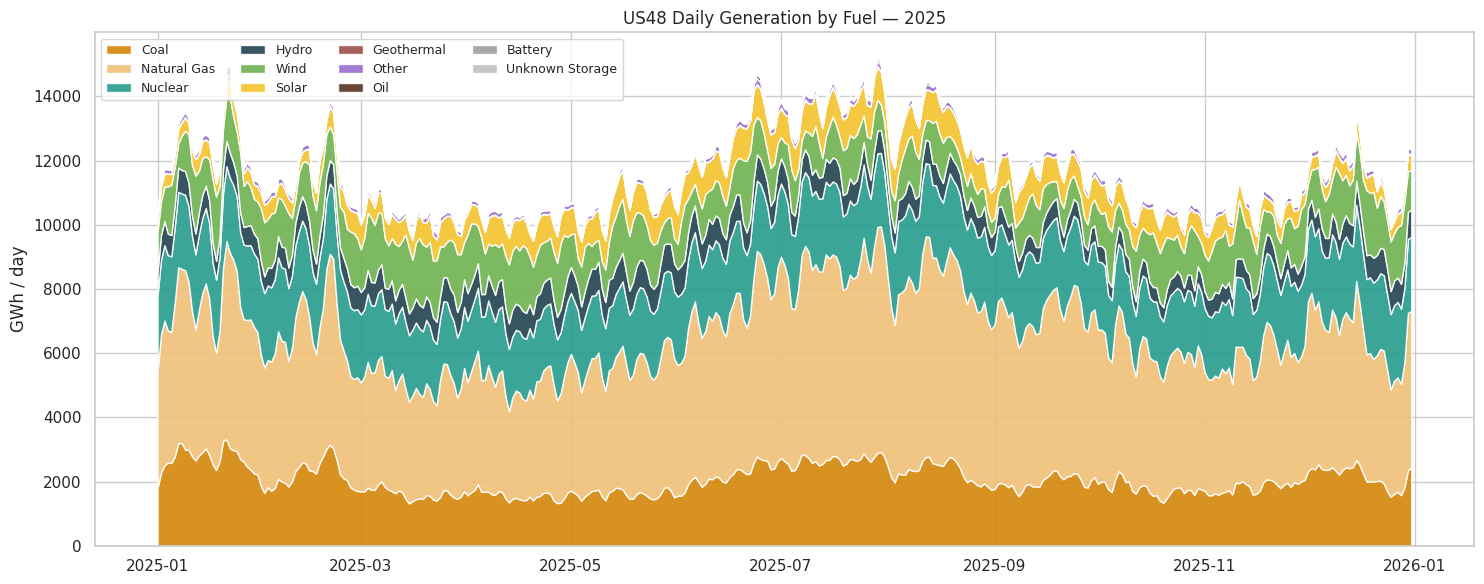

Saved us48_2025_first_look.png


In [9]:
stack_order = [c for c in ['COL', 'NG', 'NUC', 'WAT', 'WND', 'SUN', 'GEO', 'OTH', 'OIL', 'BAT', 'UES']
               if c in us48_daily.columns]
fig, ax = plt.subplots(figsize=(15, 6))
stack_data = us48_daily[stack_order].clip(lower=0)  # BAT can be negative; clip for visual
ax.stackplot(stack_data.index,
             [stack_data[c] / 1e3 for c in stack_order],  # MWh -> GWh
             labels=[FUEL_LABELS.get(c, c) for c in stack_order],
             colors=[FUEL_COLORS.get(c, '#888888') for c in stack_order],
             alpha=0.92)
ax.set_title(f'US48 Daily Generation by Fuel — {YEAR}')
ax.set_ylabel('GWh / day')
ax.legend(loc='upper left', ncol=4, fontsize=9, frameon=True)
plt.tight_layout()
out_png = PROCESSED / f'us48_{YEAR}_first_look.png'
plt.savefig(out_png, dpi=120)
plt.show()
print(f'Saved {out_png.name}')